**VAE with varying beta values**

Our original implementation defines beta (as lambda_recon) to be 0.5, that is because we consider classification loss as well as reconstruction loss, since our data supports supervised learning methods, so minimizing classification loss is an important factor. Yet we can try varying the value of beta to note the changes.


**VAE + GA (NBC)**

TESTING LAMBDA_RECON VALUES FROM 0 TO 5.0

Testing lambda_recon = 0

=== Joint Training Stage ===
  Epoch [10/50], Loss: 0.8750
  Epoch [20/50], Loss: 0.7855
  Epoch [30/50], Loss: 0.7372
  Epoch [40/50], Loss: 0.7632
  Epoch [50/50], Loss: 0.6783
VAE Training completed in 0:00:48

Running Genetic Algorithm for feature selection

GA completed in 0:00:54

GA completed: 17 features selected out of 32

Best GA fitness: 1.0000

Testing GA Selected Features with different classifiers:
  SVM - Accuracy: 96.63%, Precision: 96.85%, Recall: 97.33%, F1: 96.87%
         Training time: 0:00:00
  Naïve Bayes - Accuracy: 94.38%, Precision: 95.11%, Recall: 94.95%, F1: 94.70%
               Training time: 0:00:00
  Random Forest - Accuracy: 93.26%, Precision: 92.58%, Recall: 93.67%, F1: 92.24%
                  Training time: 0:00:00

Total time for lambda_recon=0: 0:01:42
Testing lambda_recon = 0.1

=== Joint Training Stage ===
  Epoch [10/50], Loss: 0.9163
  Epoch [20/50], Loss: 0.9506
  Epoch [30/5

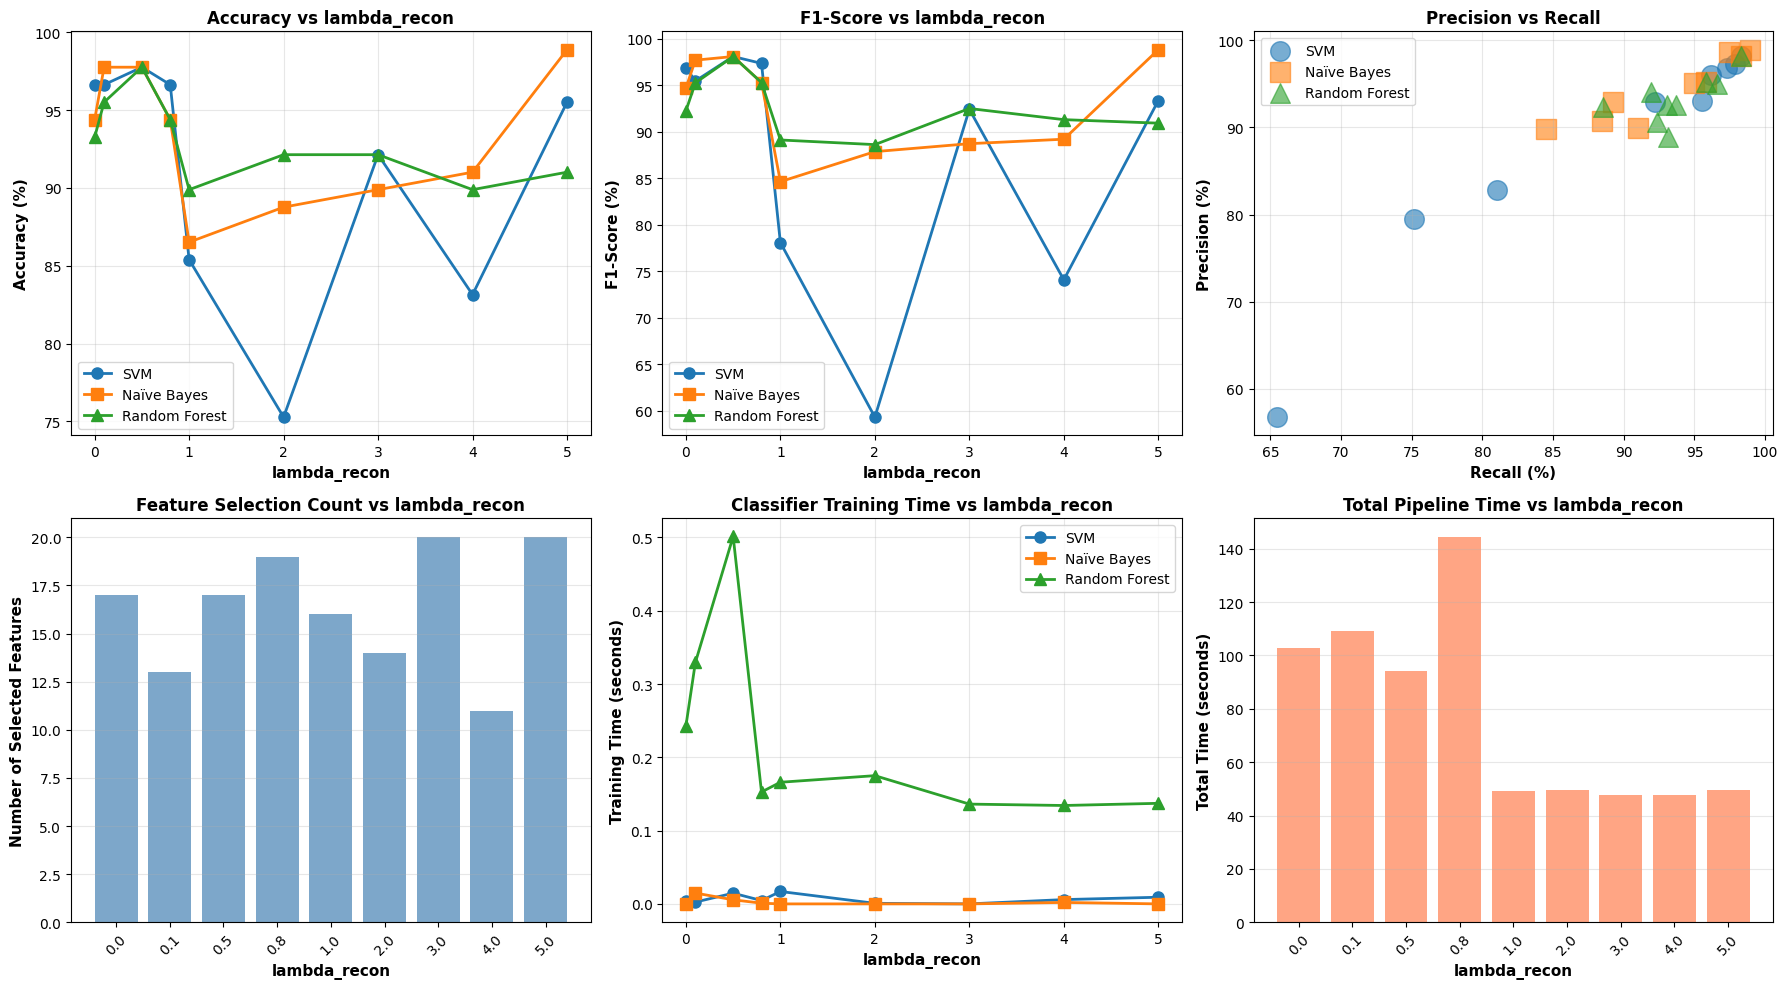


DETAILED COMPARISON TABLE - PERFORMANCE METRICS
 lambda_recon  Selected_Features SVM_Acc NBC_Acc RF_Acc SVM_F1 NBC_F1  RF_F1
          0.0                 17  96.63%  94.38% 93.26% 96.87% 94.70% 92.24%
          0.1                 13  96.63%  97.75% 95.51% 95.45% 97.69% 95.25%
          0.5                 17  97.75%  97.75% 97.75% 98.08% 98.08% 98.08%
          0.8                 19  96.63%  94.38% 94.38% 97.34% 95.28% 95.28%
          1.0                 16  85.39%  86.52% 89.89% 78.07% 84.63% 89.11%
          2.0                 14  75.28%  88.76% 92.13% 59.31% 87.86% 88.61%
          3.0                 20  92.13%  89.89% 92.13% 92.41% 88.71% 92.49%
          4.0                 11  83.15%  91.01% 89.89% 74.08% 89.19% 91.30%
          5.0                 20  95.51%  98.88% 91.01% 93.34% 98.82% 90.92%

DETAILED COMPARISON TABLE - TIMING (seconds)
 lambda_recon VAE_Train     GA SVM_Train NBC_Train RF_Train Total_Time
          0.0    48.22s 54.06s   0.0046s   0.0000s    0.24s    1

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta


# 1. Data Loading & Preparation

df = pd.read_excel('../minmax.xlsx')
data = df.values
labels = pd.read_csv('../idC_with_header.csv').values.flatten() - 1  # Adjust labels to be in range [0, 13]

X_tensor = torch.tensor(data, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.long)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Define the Joint Variational Autoencoder-Classifier Model

class JointVAEClassifier(nn.Module):
    def __init__(self, input_dim, latent_dim=32, num_classes=14):
        super(JointVAEClassifier, self).__init__()
        # Encoder
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
        )
        # Layers to produce the mean and log-variance for the latent distribution
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Decoder for reconstruction
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, input_dim),
            nn.Tanh()  
        )
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        hidden = self.encoder_net(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        
        # Reparameterize
        z = self.reparameterize(mu, logvar)
        
        # Decode and classify
        reconstruction = self.decoder(z)
        logits = self.classifier(z)
        
        return reconstruction, logits, mu, logvar


# 3. Loss Functions & Optimizer Setup

reconstruction_loss_fn = nn.MSELoss()
classification_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

def vae_combined_loss(reconstructed, original, logits, labels, mu, logvar, lambda_recon):
    loss_recon = reconstruction_loss_fn(reconstructed, original)
    loss_kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss_class = classification_loss_fn(logits, labels)
    return lambda_recon * (loss_recon + loss_kl) + (1 - lambda_recon) * loss_class

input_dim = data.shape[1]
num_classes = 14
latent_dim = 32
num_epochs = 50

# --- Genetic Algorithm Implementation ---

from deap import base, creator, tools, algorithms
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import random
import warnings
warnings.filterwarnings("ignore")

# Convert labels to NumPy arrays
y_train_np = y_train.numpy()
y_test_np = y_test.numpy()

# Define GA parameters
LATENT_FEATURES = latent_dim
N_GENERATIONS = 50
POPULATION_SIZE = 100
P_CROSSOVER = 0.7
P_MUTATION = 0.2
TOURNAMENT_SIZE = 3

# Lambda values to test
lambda_values = [0, 0.1, 0.5, 0.8, 1.0, 2.0, 3.0, 4.0, 5.0]

# Dictionary to store results for each lambda
results = {
    'lambda_recon': [],
    'VAE_Training_Time': [],
    'GA_Time': [],
    'SVM_Training_Time': [],
    'SVM_Accuracy': [],
    'SVM_Precision': [],
    'SVM_Recall': [],
    'SVM_F1': [],
    'NBC_Training_Time': [],
    'NBC_Accuracy': [],
    'NBC_Precision': [],
    'NBC_Recall': [],
    'NBC_F1': [],
    'RF_Training_Time': [],
    'RF_Accuracy': [],
    'RF_Precision': [],
    'RF_Recall': [],
    'RF_F1': [],
    'Num_Selected_Features': [],
    'Total_Time': []
}

print("TESTING LAMBDA_RECON VALUES FROM 0 TO 5.0\n")

for lambda_recon in lambda_values:
    print(f"Testing lambda_recon = {lambda_recon}\n")
    
    # Track overall time for this lambda value
    lambda_start_time = time.time()
    
    # 4. Joint Training with current lambda_recon
    
    print("=== Joint Training Stage ===")
    vae_start_time = time.time()
    
    model = JointVAEClassifier(input_dim, latent_dim, num_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels_batch in train_loader:
            optimizer.zero_grad()
            reconstruction, logits, mu, logvar = model(inputs)
            loss = vae_combined_loss(reconstruction, inputs, logits, labels_batch, mu, logvar, lambda_recon)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")
    
    vae_training_time = time.time() - vae_start_time
    print(f"VAE Training completed in {timedelta(seconds=int(vae_training_time))}")
    
    # 5. Extract Latent Features Using the Trained Encoder
    
    model.eval()
    with torch.no_grad():
        train_encoded = model.encoder_net(X_train)
        train_latent = model.fc_mu(train_encoded).numpy()
        
        test_encoded = model.encoder_net(X_test)
        test_latent = model.fc_mu(test_encoded).numpy()
    
    print("\nRunning Genetic Algorithm for feature selection")
    ga_start_time = time.time()
    
    # Clean up DEAP creators
    try:
        del creator.FitnessMax
        del creator.Individual
    except:
        pass
    
    # Create types for GA
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    
    toolbox = base.Toolbox()
    
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=LATENT_FEATURES)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    
    def evaluate_individual_with_latent(individual):
        # Get selected latent features
        selected_indices = [i for i, val in enumerate(individual) if val == 1]
        
        # If too few features are selected, penalize the individual
        if len(selected_indices) < 2:
            return 0.0,
        
        # Create a modified input tensor with zeros for non-selected features
        modified_latent = train_latent[:, selected_indices]
        
        # Train a simple classifier on the selected latent features
        classifier = GaussianNB()
        scores = cross_val_score(classifier, modified_latent, y_train_np, cv=5)
        accuracy = scores.mean()

        return accuracy,
    
    toolbox.register("evaluate", evaluate_individual_with_latent)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)
    
    def run_ga():
        # Initialize population
        population = toolbox.population(n=POPULATION_SIZE)
        
        # Statistics to track progress
        stats = tools.Statistics(lambda ind: ind.fitness.values)
        stats.register("avg", np.mean)
        stats.register("std", np.std)
        stats.register("min", np.min)
        stats.register("max", np.max)
        
        # Hall of fame to keep track of best individuals
        hof = tools.HallOfFame(1)
        
        # Running the algorithm
        population, logbook = algorithms.eaSimple(
            population, 
            toolbox, 
            cxpb=P_CROSSOVER, 
            mutpb=P_MUTATION, 
            ngen=N_GENERATIONS, 
            stats=stats, 
            halloffame=hof, 
            verbose=False
        )
        
        return population, logbook, hof
    
    population, logbook, hof = run_ga()
    
    ga_time = time.time() - ga_start_time
    print(f"\nGA completed in {timedelta(seconds=int(ga_time))}")
    
    # Get the best individual
    best_individual = hof[0]
    selected_latent_features = [i for i, val in enumerate(best_individual) if val == 1]
    num_selected = len(selected_latent_features)
    
    print(f"\nGA completed: {num_selected} features selected out of {LATENT_FEATURES}")
    print(f"\nBest GA fitness: {best_individual.fitness.values[0]:.4f}")
    
    # Testing the GA selected features on the models
    print("\nTesting GA Selected Features with different classifiers:")
    modified_latent_train = train_latent[:, selected_latent_features]
    modified_latent_test = test_latent[:, selected_latent_features]
    
    # --- SVM Classifier ---
    svm_start_time = time.time()
    svm_model = SVC(random_state=42)
    svm_model.fit(modified_latent_train, y_train_np)
    svm_preds = svm_model.predict(modified_latent_test)
    svm_training_time = time.time() - svm_start_time
    
    svm_acc = accuracy_score(y_test_np, svm_preds)
    svm_precision = precision_score(y_test_np, svm_preds, average='macro')
    svm_recall = recall_score(y_test_np, svm_preds, average='macro')
    svm_f1 = f1_score(y_test_np, svm_preds, average='macro')
    
    print(f"  SVM - Accuracy: {svm_acc * 100:.2f}%, Precision: {svm_precision * 100:.2f}%, Recall: {svm_recall * 100:.2f}%, F1: {svm_f1 * 100:.2f}%")
    print(f"         Training time: {timedelta(seconds=int(svm_training_time))}")
    
    # --- Naïve Bayes Classifier ---
    nbc_start_time = time.time()
    nbc_model = GaussianNB()
    nbc_model.fit(modified_latent_train, y_train_np)
    nbc_preds = nbc_model.predict(modified_latent_test)
    nbc_training_time = time.time() - nbc_start_time
    
    nbc_acc = accuracy_score(y_test_np, nbc_preds)
    nbc_precision = precision_score(y_test_np, nbc_preds, average='macro')
    nbc_recall = recall_score(y_test_np, nbc_preds, average='macro')
    nbc_f1 = f1_score(y_test_np, nbc_preds, average='macro')
    
    print(f"  Naïve Bayes - Accuracy: {nbc_acc * 100:.2f}%, Precision: {nbc_precision * 100:.2f}%, Recall: {nbc_recall * 100:.2f}%, F1: {nbc_f1 * 100:.2f}%")
    print(f"               Training time: {timedelta(seconds=int(nbc_training_time))}")
    
    # --- Random Forest Classifier ---
    rf_start_time = time.time()
    rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_model.fit(modified_latent_train, y_train_np)
    rf_preds = rf_model.predict(modified_latent_test)
    rf_training_time = time.time() - rf_start_time
    
    rf_acc = accuracy_score(y_test_np, rf_preds)
    rf_precision = precision_score(y_test_np, rf_preds, average='macro')
    rf_recall = recall_score(y_test_np, rf_preds, average='macro')
    rf_f1 = f1_score(y_test_np, rf_preds, average='macro')
    
    print(f"  Random Forest - Accuracy: {rf_acc * 100:.2f}%, Precision: {rf_precision * 100:.2f}%, Recall: {rf_recall * 100:.2f}%, F1: {rf_f1 * 100:.2f}%")
    print(f"                  Training time: {timedelta(seconds=int(rf_training_time))}")
    
    # Calculate total time for this lambda
    total_lambda_time = time.time() - lambda_start_time
    print(f"\nTotal time for lambda_recon={lambda_recon}: {timedelta(seconds=int(total_lambda_time))}")
    
    # Store results
    results['lambda_recon'].append(lambda_recon)
    results['VAE_Training_Time'].append(vae_training_time)
    results['GA_Time'].append(ga_time)
    results['SVM_Training_Time'].append(svm_training_time)
    results['SVM_Accuracy'].append(svm_acc)
    results['SVM_Precision'].append(svm_precision)
    results['SVM_Recall'].append(svm_recall)
    results['SVM_F1'].append(svm_f1)
    results['NBC_Training_Time'].append(nbc_training_time)
    results['NBC_Accuracy'].append(nbc_acc)
    results['NBC_Precision'].append(nbc_precision)
    results['NBC_Recall'].append(nbc_recall)
    results['NBC_F1'].append(nbc_f1)
    results['RF_Training_Time'].append(rf_training_time)
    results['RF_Accuracy'].append(rf_acc)
    results['RF_Precision'].append(rf_precision)
    results['RF_Recall'].append(rf_recall)
    results['RF_F1'].append(rf_f1)
    results['Num_Selected_Features'].append(num_selected)
    results['Total_Time'].append(total_lambda_time)

print(f"\n{'=' * 80}")
print("EXPERIMENT COMPLETED")
print(f"{'=' * 80}\n")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("Summary of Results:")
print(results_df.to_string(index=False))

# Save results to CSV
#results_df.to_csv('lambda_recon_results.csv', index=False)
#print("\nResults saved to 'lambda_recon_results.csv'")

# 6. Visualization of Results

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Accuracy Comparison
axes[0, 0].plot(results['lambda_recon'], np.array(results['SVM_Accuracy']) * 100, 'o-', label='SVM', linewidth=2, markersize=8)
axes[0, 0].plot(results['lambda_recon'], np.array(results['NBC_Accuracy']) * 100, 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[0, 0].plot(results['lambda_recon'], np.array(results['RF_Accuracy']) * 100, '^-', label='Random Forest', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Accuracy vs lambda_recon', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: F1-Score Comparison
axes[0, 1].plot(results['lambda_recon'], np.array(results['SVM_F1']) * 100, 'o-', label='SVM', linewidth=2, markersize=8)
axes[0, 1].plot(results['lambda_recon'], np.array(results['NBC_F1']) * 100, 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[0, 1].plot(results['lambda_recon'], np.array(results['RF_F1']) * 100, '^-', label='Random Forest', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('F1-Score (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('F1-Score vs lambda_recon', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision vs Recall
axes[0, 2].scatter(np.array(results['SVM_Recall']) * 100, np.array(results['SVM_Precision']) * 100, 
                   s=200, alpha=0.6, label='SVM', marker='o')
axes[0, 2].scatter(np.array(results['NBC_Recall']) * 100, np.array(results['NBC_Precision']) * 100, 
                   s=200, alpha=0.6, label='Naïve Bayes', marker='s')
axes[0, 2].scatter(np.array(results['RF_Recall']) * 100, np.array(results['RF_Precision']) * 100, 
                   s=200, alpha=0.6, label='Random Forest', marker='^')
axes[0, 2].set_xlabel('Recall (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Precision vs Recall', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Number of Selected Features
axes[1, 0].bar(range(len(results['lambda_recon'])), results['Num_Selected_Features'], color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Number of Selected Features', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Feature Selection Count vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(len(results['lambda_recon'])))
axes[1, 0].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: Training Time Comparison (in seconds)
axes[1, 1].plot(results['lambda_recon'], results['SVM_Training_Time'], 'o-', label='SVM', linewidth=2, markersize=8)
axes[1, 1].plot(results['lambda_recon'], results['NBC_Training_Time'], 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[1, 1].plot(results['lambda_recon'], results['RF_Training_Time'], '^-', label='Random Forest', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Training Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Classifier Training Time vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Total Pipeline Time per Lambda
axes[1, 2].bar(range(len(results['lambda_recon'])), results['Total_Time'], color='coral', alpha=0.7)
axes[1, 2].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('Total Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Total Pipeline Time vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(range(len(results['lambda_recon'])))
axes[1, 2].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lambda_recon_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved to 'lambda_recon_analysis.png'")
plt.show()

# Additional detailed comparison table
print("\n" + "=" * 120)
print("DETAILED COMPARISON TABLE - PERFORMANCE METRICS")
print("=" * 120)

comparison_table = pd.DataFrame({
    'lambda_recon': results['lambda_recon'],
    'Selected_Features': results['Num_Selected_Features'],
    'SVM_Acc': [f"{x*100:.2f}%" for x in results['SVM_Accuracy']],
    'NBC_Acc': [f"{x*100:.2f}%" for x in results['NBC_Accuracy']],
    'RF_Acc': [f"{x*100:.2f}%" for x in results['RF_Accuracy']],
    'SVM_F1': [f"{x*100:.2f}%" for x in results['SVM_F1']],
    'NBC_F1': [f"{x*100:.2f}%" for x in results['NBC_F1']],
    'RF_F1': [f"{x*100:.2f}%" for x in results['RF_F1']],
})

print(comparison_table.to_string(index=False))

print("\n" + "=" * 120)
print("DETAILED COMPARISON TABLE - TIMING (seconds)")
print("=" * 120)

timing_table = pd.DataFrame({
    'lambda_recon': results['lambda_recon'],
    'VAE_Train': [f"{x:.2f}s" for x in results['VAE_Training_Time']],
    'GA': [f"{x:.2f}s" for x in results['GA_Time']],
    'SVM_Train': [f"{x:.4f}s" for x in results['SVM_Training_Time']],
    'NBC_Train': [f"{x:.4f}s" for x in results['NBC_Training_Time']],
    'RF_Train': [f"{x:.2f}s" for x in results['RF_Training_Time']],
    'Total_Time': [f"{x:.2f}s" for x in results['Total_Time']],
})

print(timing_table.to_string(index=False))

print("\n" + "=" * 120)

**VAE + GA (SVC)**

TESTING LAMBDA_RECON VALUES FROM 0 TO 5.0

Testing lambda_recon = 0

=== Joint Training Stage ===
  Epoch [10/50], Loss: 0.9488
  Epoch [20/50], Loss: 0.7591
  Epoch [30/50], Loss: 0.8614
  Epoch [40/50], Loss: 0.6926
  Epoch [50/50], Loss: 0.8100
VAE Training completed in 0:00:27

Running Genetic Algorithm for feature selection

GA completed in 0:02:30

GA completed: 18 features selected out of 32

Best GA fitness: 1.0000

Testing GA Selected Features with different classifiers:
  SVM - Accuracy: 97.75%, Precision: 98.13%, Recall: 98.29%, F1: 98.08%
         Training time: 0:00:00
  Naïve Bayes - Accuracy: 95.51%, Precision: 96.45%, Recall: 96.76%, F1: 96.30%
               Training time: 0:00:00
  Random Forest - Accuracy: 95.51%, Precision: 94.63%, Recall: 97.22%, F1: 95.36%
                  Training time: 0:00:00

Total time for lambda_recon=0: 0:02:58
Testing lambda_recon = 0.1

=== Joint Training Stage ===
  Epoch [10/50], Loss: 0.8965
  Epoch [20/50], Loss: 0.8519
  Epoch [30/5

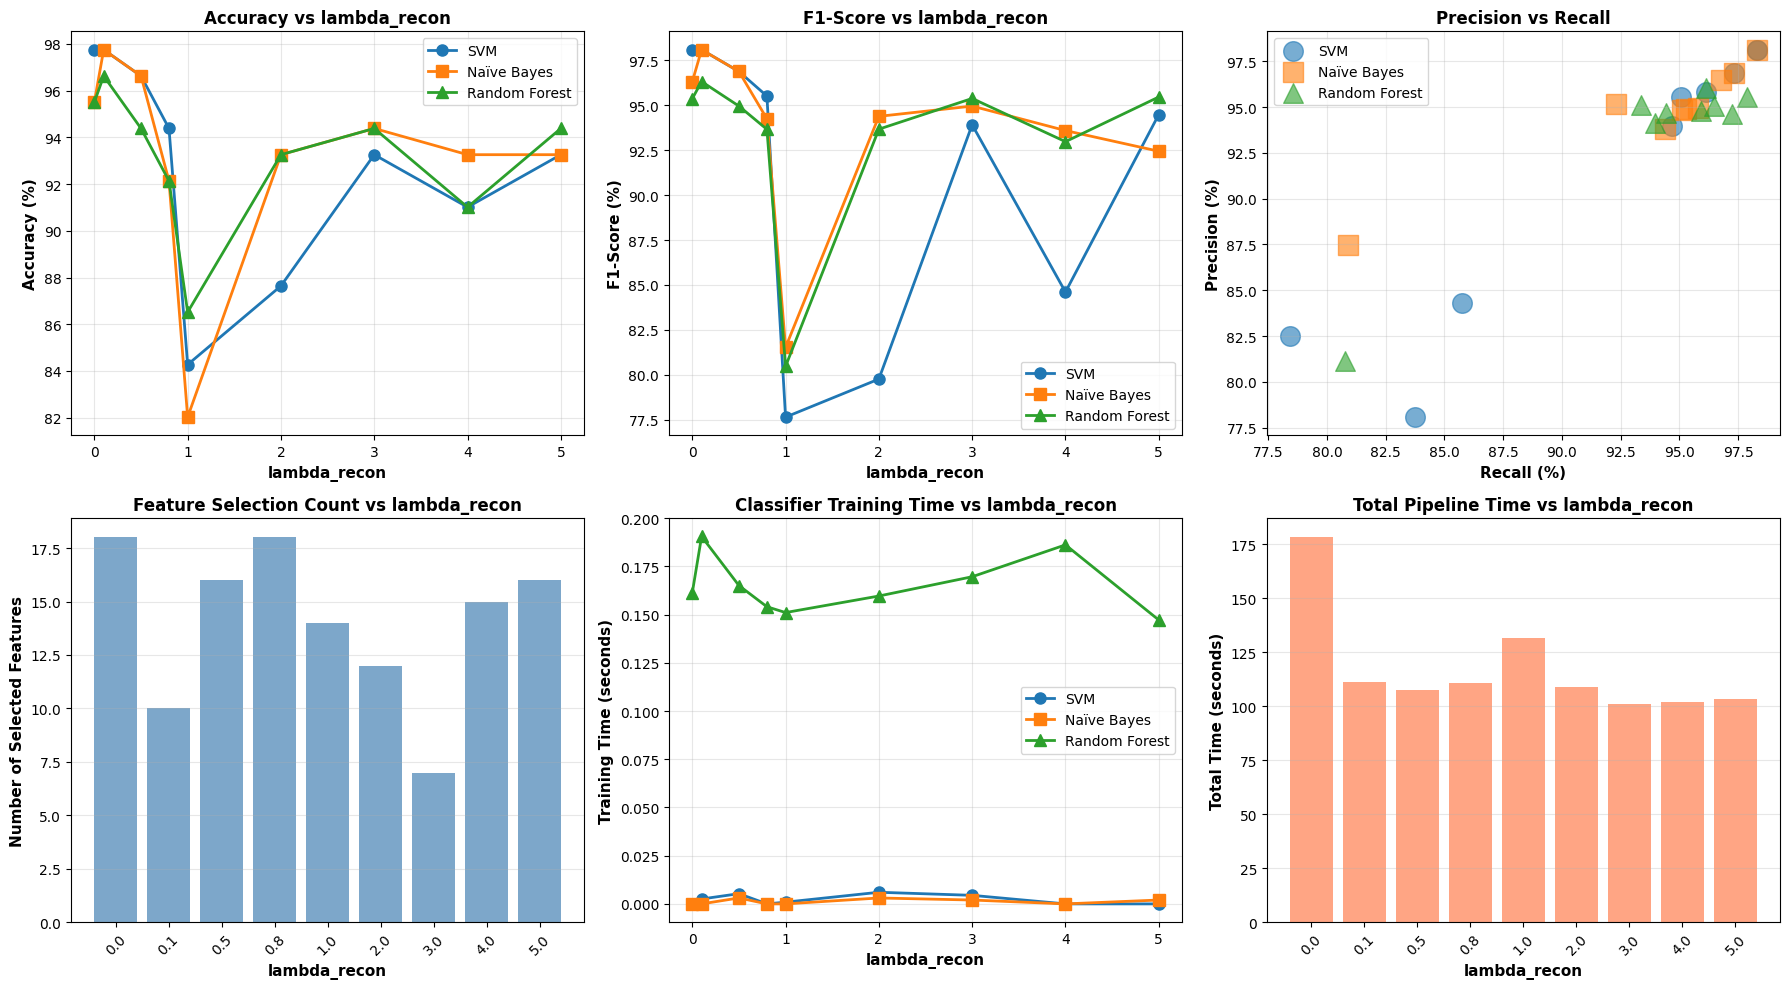


DETAILED COMPARISON TABLE - PERFORMANCE METRICS
 lambda_recon  Selected_Features SVM_Acc NBC_Acc RF_Acc SVM_F1 NBC_F1  RF_F1
          0.0                 18  97.75%  95.51% 95.51% 98.08% 96.30% 95.36%
          0.1                 10  97.75%  97.75% 96.63% 98.08% 98.08% 96.31%
          0.5                 16  96.63%  96.63% 94.38% 96.87% 96.87% 94.95%
          0.8                 18  94.38%  92.13% 92.13% 95.51% 94.24% 93.66%
          1.0                 14  84.27%  82.02% 86.52% 77.65% 81.53% 80.48%
          2.0                 12  87.64%  93.26% 93.26% 79.77% 94.38% 93.66%
          3.0                  7  93.26%  94.38% 94.38% 93.91% 94.95% 95.37%
          4.0                 15  91.01%  93.26% 91.01% 84.61% 93.59% 92.97%
          5.0                 16  93.26%  93.26% 94.38% 94.48% 92.44% 95.45%

DETAILED COMPARISON TABLE - TIMING (seconds)
 lambda_recon VAE_Train      GA SVM_Train NBC_Train RF_Train Total_Time
          0.0    27.87s 150.13s   0.0000s   0.0000s    0.16s   

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta


# 1. Data Loading & Preparation

df = pd.read_excel('../minmax.xlsx')
data = df.values
labels = pd.read_csv('../idC_with_header.csv').values.flatten() - 1  # Adjust labels to be in range [0, 13]

X_tensor = torch.tensor(data, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.long)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Define the Joint Variational Autoencoder-Classifier Model

class JointVAEClassifier(nn.Module):
    def __init__(self, input_dim, latent_dim=32, num_classes=14):
        super(JointVAEClassifier, self).__init__()
        # Encoder
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
        )
        # Layers to produce the mean and log-variance for the latent distribution
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Decoder for reconstruction
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, input_dim),
            nn.Tanh()  
        )
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        hidden = self.encoder_net(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        
        # Reparameterize
        z = self.reparameterize(mu, logvar)
        
        # Decode and classify
        reconstruction = self.decoder(z)
        logits = self.classifier(z)
        
        return reconstruction, logits, mu, logvar


# 3. Loss Functions & Optimizer Setup

reconstruction_loss_fn = nn.MSELoss()
classification_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

def vae_combined_loss(reconstructed, original, logits, labels, mu, logvar, lambda_recon):
    loss_recon = reconstruction_loss_fn(reconstructed, original)
    loss_kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss_class = classification_loss_fn(logits, labels)
    return lambda_recon * (loss_recon + loss_kl) + (1 - lambda_recon) * loss_class

input_dim = data.shape[1]
num_classes = 14
latent_dim = 32
num_epochs = 50

# --- Genetic Algorithm Implementation ---

from deap import base, creator, tools, algorithms
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import random
import warnings
warnings.filterwarnings("ignore")

# Convert labels to NumPy arrays
y_train_np = y_train.numpy()
y_test_np = y_test.numpy()

# Define GA parameters
LATENT_FEATURES = latent_dim
N_GENERATIONS = 50
POPULATION_SIZE = 100
P_CROSSOVER = 0.7
P_MUTATION = 0.2
TOURNAMENT_SIZE = 3

# Lambda values to test
lambda_values = [0, 0.1, 0.5, 0.8, 1.0, 2.0, 3.0, 4.0, 5.0]

# Dictionary to store results for each lambda
results = {
    'lambda_recon': [],
    'VAE_Training_Time': [],
    'GA_Time': [],
    'SVM_Training_Time': [],
    'SVM_Accuracy': [],
    'SVM_Precision': [],
    'SVM_Recall': [],
    'SVM_F1': [],
    'NBC_Training_Time': [],
    'NBC_Accuracy': [],
    'NBC_Precision': [],
    'NBC_Recall': [],
    'NBC_F1': [],
    'RF_Training_Time': [],
    'RF_Accuracy': [],
    'RF_Precision': [],
    'RF_Recall': [],
    'RF_F1': [],
    'Num_Selected_Features': [],
    'Total_Time': []
}

print("TESTING LAMBDA_RECON VALUES FROM 0 TO 5.0\n")

for lambda_recon in lambda_values:
    print(f"Testing lambda_recon = {lambda_recon}\n")
    
    # Track overall time for this lambda value
    lambda_start_time = time.time()
    
    # 4. Joint Training with current lambda_recon
    
    print("=== Joint Training Stage ===")
    vae_start_time = time.time()
    
    model = JointVAEClassifier(input_dim, latent_dim, num_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels_batch in train_loader:
            optimizer.zero_grad()
            reconstruction, logits, mu, logvar = model(inputs)
            loss = vae_combined_loss(reconstruction, inputs, logits, labels_batch, mu, logvar, lambda_recon)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")
    
    vae_training_time = time.time() - vae_start_time
    print(f"VAE Training completed in {timedelta(seconds=int(vae_training_time))}")
    
    # 5. Extract Latent Features Using the Trained Encoder
    
    model.eval()
    with torch.no_grad():
        train_encoded = model.encoder_net(X_train)
        train_latent = model.fc_mu(train_encoded).numpy()
        
        test_encoded = model.encoder_net(X_test)
        test_latent = model.fc_mu(test_encoded).numpy()
    
    print("\nRunning Genetic Algorithm for feature selection")
    ga_start_time = time.time()
    
    # Clean up DEAP creators
    try:
        del creator.FitnessMax
        del creator.Individual
    except:
        pass
    
    # Create types for GA
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    
    toolbox = base.Toolbox()
    
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=LATENT_FEATURES)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    
    def evaluate_individual_with_latent(individual):
        # Get selected latent features
        selected_indices = [i for i, val in enumerate(individual) if val == 1]
        
        # If too few features are selected, penalize the individual
        if len(selected_indices) < 2:
            return 0.0,
        
        # Create a modified input tensor with zeros for non-selected features
        modified_latent = train_latent[:, selected_indices]
        
        # Train a simple classifier on the selected latent features
        classifier = SVC(random_state=42)
        scores = cross_val_score(classifier, modified_latent, y_train_np, cv=5)
        accuracy = scores.mean()

        return accuracy,
    
    toolbox.register("evaluate", evaluate_individual_with_latent)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)
    
    def run_ga():
        # Initialize population
        population = toolbox.population(n=POPULATION_SIZE)
        
        # Statistics to track progress
        stats = tools.Statistics(lambda ind: ind.fitness.values)
        stats.register("avg", np.mean)
        stats.register("std", np.std)
        stats.register("min", np.min)
        stats.register("max", np.max)
        
        # Hall of fame to keep track of best individuals
        hof = tools.HallOfFame(1)
        
        # Running the algorithm
        population, logbook = algorithms.eaSimple(
            population, 
            toolbox, 
            cxpb=P_CROSSOVER, 
            mutpb=P_MUTATION, 
            ngen=N_GENERATIONS, 
            stats=stats, 
            halloffame=hof, 
            verbose=False
        )
        
        return population, logbook, hof
    
    population, logbook, hof = run_ga()
    
    ga_time = time.time() - ga_start_time
    print(f"\nGA completed in {timedelta(seconds=int(ga_time))}")
    
    # Get the best individual
    best_individual = hof[0]
    selected_latent_features = [i for i, val in enumerate(best_individual) if val == 1]
    num_selected = len(selected_latent_features)
    
    print(f"\nGA completed: {num_selected} features selected out of {LATENT_FEATURES}")
    print(f"\nBest GA fitness: {best_individual.fitness.values[0]:.4f}")
    
    # Testing the GA selected features on the models
    print("\nTesting GA Selected Features with different classifiers:")
    modified_latent_train = train_latent[:, selected_latent_features]
    modified_latent_test = test_latent[:, selected_latent_features]
    
    # --- SVM Classifier ---
    svm_start_time = time.time()
    svm_model = SVC(random_state=42)
    svm_model.fit(modified_latent_train, y_train_np)
    svm_preds = svm_model.predict(modified_latent_test)
    svm_training_time = time.time() - svm_start_time
    
    svm_acc = accuracy_score(y_test_np, svm_preds)
    svm_precision = precision_score(y_test_np, svm_preds, average='macro')
    svm_recall = recall_score(y_test_np, svm_preds, average='macro')
    svm_f1 = f1_score(y_test_np, svm_preds, average='macro')
    
    print(f"  SVM - Accuracy: {svm_acc * 100:.2f}%, Precision: {svm_precision * 100:.2f}%, Recall: {svm_recall * 100:.2f}%, F1: {svm_f1 * 100:.2f}%")
    print(f"         Training time: {timedelta(seconds=int(svm_training_time))}")
    
    # --- Naïve Bayes Classifier ---
    nbc_start_time = time.time()
    nbc_model = GaussianNB()
    nbc_model.fit(modified_latent_train, y_train_np)
    nbc_preds = nbc_model.predict(modified_latent_test)
    nbc_training_time = time.time() - nbc_start_time
    
    nbc_acc = accuracy_score(y_test_np, nbc_preds)
    nbc_precision = precision_score(y_test_np, nbc_preds, average='macro')
    nbc_recall = recall_score(y_test_np, nbc_preds, average='macro')
    nbc_f1 = f1_score(y_test_np, nbc_preds, average='macro')
    
    print(f"  Naïve Bayes - Accuracy: {nbc_acc * 100:.2f}%, Precision: {nbc_precision * 100:.2f}%, Recall: {nbc_recall * 100:.2f}%, F1: {nbc_f1 * 100:.2f}%")
    print(f"               Training time: {timedelta(seconds=int(nbc_training_time))}")
    
    # --- Random Forest Classifier ---
    rf_start_time = time.time()
    rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_model.fit(modified_latent_train, y_train_np)
    rf_preds = rf_model.predict(modified_latent_test)
    rf_training_time = time.time() - rf_start_time
    
    rf_acc = accuracy_score(y_test_np, rf_preds)
    rf_precision = precision_score(y_test_np, rf_preds, average='macro')
    rf_recall = recall_score(y_test_np, rf_preds, average='macro')
    rf_f1 = f1_score(y_test_np, rf_preds, average='macro')
    
    print(f"  Random Forest - Accuracy: {rf_acc * 100:.2f}%, Precision: {rf_precision * 100:.2f}%, Recall: {rf_recall * 100:.2f}%, F1: {rf_f1 * 100:.2f}%")
    print(f"                  Training time: {timedelta(seconds=int(rf_training_time))}")
    
    # Calculate total time for this lambda
    total_lambda_time = time.time() - lambda_start_time
    print(f"\nTotal time for lambda_recon={lambda_recon}: {timedelta(seconds=int(total_lambda_time))}")
    
    # Store results
    results['lambda_recon'].append(lambda_recon)
    results['VAE_Training_Time'].append(vae_training_time)
    results['GA_Time'].append(ga_time)
    results['SVM_Training_Time'].append(svm_training_time)
    results['SVM_Accuracy'].append(svm_acc)
    results['SVM_Precision'].append(svm_precision)
    results['SVM_Recall'].append(svm_recall)
    results['SVM_F1'].append(svm_f1)
    results['NBC_Training_Time'].append(nbc_training_time)
    results['NBC_Accuracy'].append(nbc_acc)
    results['NBC_Precision'].append(nbc_precision)
    results['NBC_Recall'].append(nbc_recall)
    results['NBC_F1'].append(nbc_f1)
    results['RF_Training_Time'].append(rf_training_time)
    results['RF_Accuracy'].append(rf_acc)
    results['RF_Precision'].append(rf_precision)
    results['RF_Recall'].append(rf_recall)
    results['RF_F1'].append(rf_f1)
    results['Num_Selected_Features'].append(num_selected)
    results['Total_Time'].append(total_lambda_time)

print(f"\n{'=' * 80}")
print("EXPERIMENT COMPLETED")
print(f"{'=' * 80}\n")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("Summary of Results:")
print(results_df.to_string(index=False))

# Save results to CSV
#results_df.to_csv('lambda_recon_results.csv', index=False)
#print("\nResults saved to 'lambda_recon_results.csv'")

# 6. Visualization of Results

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Accuracy Comparison
axes[0, 0].plot(results['lambda_recon'], np.array(results['SVM_Accuracy']) * 100, 'o-', label='SVM', linewidth=2, markersize=8)
axes[0, 0].plot(results['lambda_recon'], np.array(results['NBC_Accuracy']) * 100, 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[0, 0].plot(results['lambda_recon'], np.array(results['RF_Accuracy']) * 100, '^-', label='Random Forest', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Accuracy vs lambda_recon', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: F1-Score Comparison
axes[0, 1].plot(results['lambda_recon'], np.array(results['SVM_F1']) * 100, 'o-', label='SVM', linewidth=2, markersize=8)
axes[0, 1].plot(results['lambda_recon'], np.array(results['NBC_F1']) * 100, 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[0, 1].plot(results['lambda_recon'], np.array(results['RF_F1']) * 100, '^-', label='Random Forest', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('F1-Score (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('F1-Score vs lambda_recon', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision vs Recall
axes[0, 2].scatter(np.array(results['SVM_Recall']) * 100, np.array(results['SVM_Precision']) * 100, 
                   s=200, alpha=0.6, label='SVM', marker='o')
axes[0, 2].scatter(np.array(results['NBC_Recall']) * 100, np.array(results['NBC_Precision']) * 100, 
                   s=200, alpha=0.6, label='Naïve Bayes', marker='s')
axes[0, 2].scatter(np.array(results['RF_Recall']) * 100, np.array(results['RF_Precision']) * 100, 
                   s=200, alpha=0.6, label='Random Forest', marker='^')
axes[0, 2].set_xlabel('Recall (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Precision vs Recall', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Number of Selected Features
axes[1, 0].bar(range(len(results['lambda_recon'])), results['Num_Selected_Features'], color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Number of Selected Features', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Feature Selection Count vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(len(results['lambda_recon'])))
axes[1, 0].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: Training Time Comparison (in seconds)
axes[1, 1].plot(results['lambda_recon'], results['SVM_Training_Time'], 'o-', label='SVM', linewidth=2, markersize=8)
axes[1, 1].plot(results['lambda_recon'], results['NBC_Training_Time'], 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[1, 1].plot(results['lambda_recon'], results['RF_Training_Time'], '^-', label='Random Forest', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Training Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Classifier Training Time vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Total Pipeline Time per Lambda
axes[1, 2].bar(range(len(results['lambda_recon'])), results['Total_Time'], color='coral', alpha=0.7)
axes[1, 2].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('Total Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Total Pipeline Time vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(range(len(results['lambda_recon'])))
axes[1, 2].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('lambda_recon_analysis.png', dpi=300, bbox_inches='tight')
#print("Visualization saved to 'lambda_recon_analysis.png'")
plt.show()

# Additional detailed comparison table
print("\n" + "=" * 120)
print("DETAILED COMPARISON TABLE - PERFORMANCE METRICS")
print("=" * 120)

comparison_table = pd.DataFrame({
    'lambda_recon': results['lambda_recon'],
    'Selected_Features': results['Num_Selected_Features'],
    'SVM_Acc': [f"{x*100:.2f}%" for x in results['SVM_Accuracy']],
    'NBC_Acc': [f"{x*100:.2f}%" for x in results['NBC_Accuracy']],
    'RF_Acc': [f"{x*100:.2f}%" for x in results['RF_Accuracy']],
    'SVM_F1': [f"{x*100:.2f}%" for x in results['SVM_F1']],
    'NBC_F1': [f"{x*100:.2f}%" for x in results['NBC_F1']],
    'RF_F1': [f"{x*100:.2f}%" for x in results['RF_F1']],
})

print(comparison_table.to_string(index=False))

print("\n" + "=" * 120)
print("DETAILED COMPARISON TABLE - TIMING (seconds)")
print("=" * 120)

timing_table = pd.DataFrame({
    'lambda_recon': results['lambda_recon'],
    'VAE_Train': [f"{x:.2f}s" for x in results['VAE_Training_Time']],
    'GA': [f"{x:.2f}s" for x in results['GA_Time']],
    'SVM_Train': [f"{x:.4f}s" for x in results['SVM_Training_Time']],
    'NBC_Train': [f"{x:.4f}s" for x in results['NBC_Training_Time']],
    'RF_Train': [f"{x:.2f}s" for x in results['RF_Training_Time']],
    'Total_Time': [f"{x:.2f}s" for x in results['Total_Time']],
})

print(timing_table.to_string(index=False))

print("\n" + "=" * 120)

**VAE + GA (RF)**

**stopping criteria addition**

TESTING LAMBDA_RECON VALUES FROM 0 TO 5.0 (WITH EARLY STOPPING GA)

GA Early Stopping Settings:
  - Patience: 10 generations
  - Max Time: 300 seconds (~5.0 minutes)
  - Min Improvement Threshold: 0.001
  - Population Size: 50


Testing lambda_recon = 0
=== Joint Training Stage ===
  Epoch [10/50], Loss: 0.8623
  Epoch [20/50], Loss: 0.8210
  Epoch [30/50], Loss: 0.8668
  Epoch [40/50], Loss: 0.9077
  Epoch [50/50], Loss: 0.7781
VAE Training completed in 0:00:12

Running Genetic Algorithm for feature selection (with early stopping)...

  ⏱️  GA Timeout: Exceeded 300s limit at generation 8
  Final: Ran 8/50 generations in 0:05:18

GA Result: 21 features selected out of 32
Best GA fitness: 1.0000

Testing GA Selected Features with different classifiers:
  SVM - Acc: 96.63%, Prec: 97.50%, Rec: 97.01%, F1: 96.88%
  NBC - Acc: 97.75%, Prec: 98.13%, Rec: 98.29%, F1: 98.08%
  RF  - Acc: 96.63%, Prec: 97.17%, Rec: 97.01%, F1: 96.87%

Total time for lambda_recon=0: 0:05:31

Testing lambda_recon

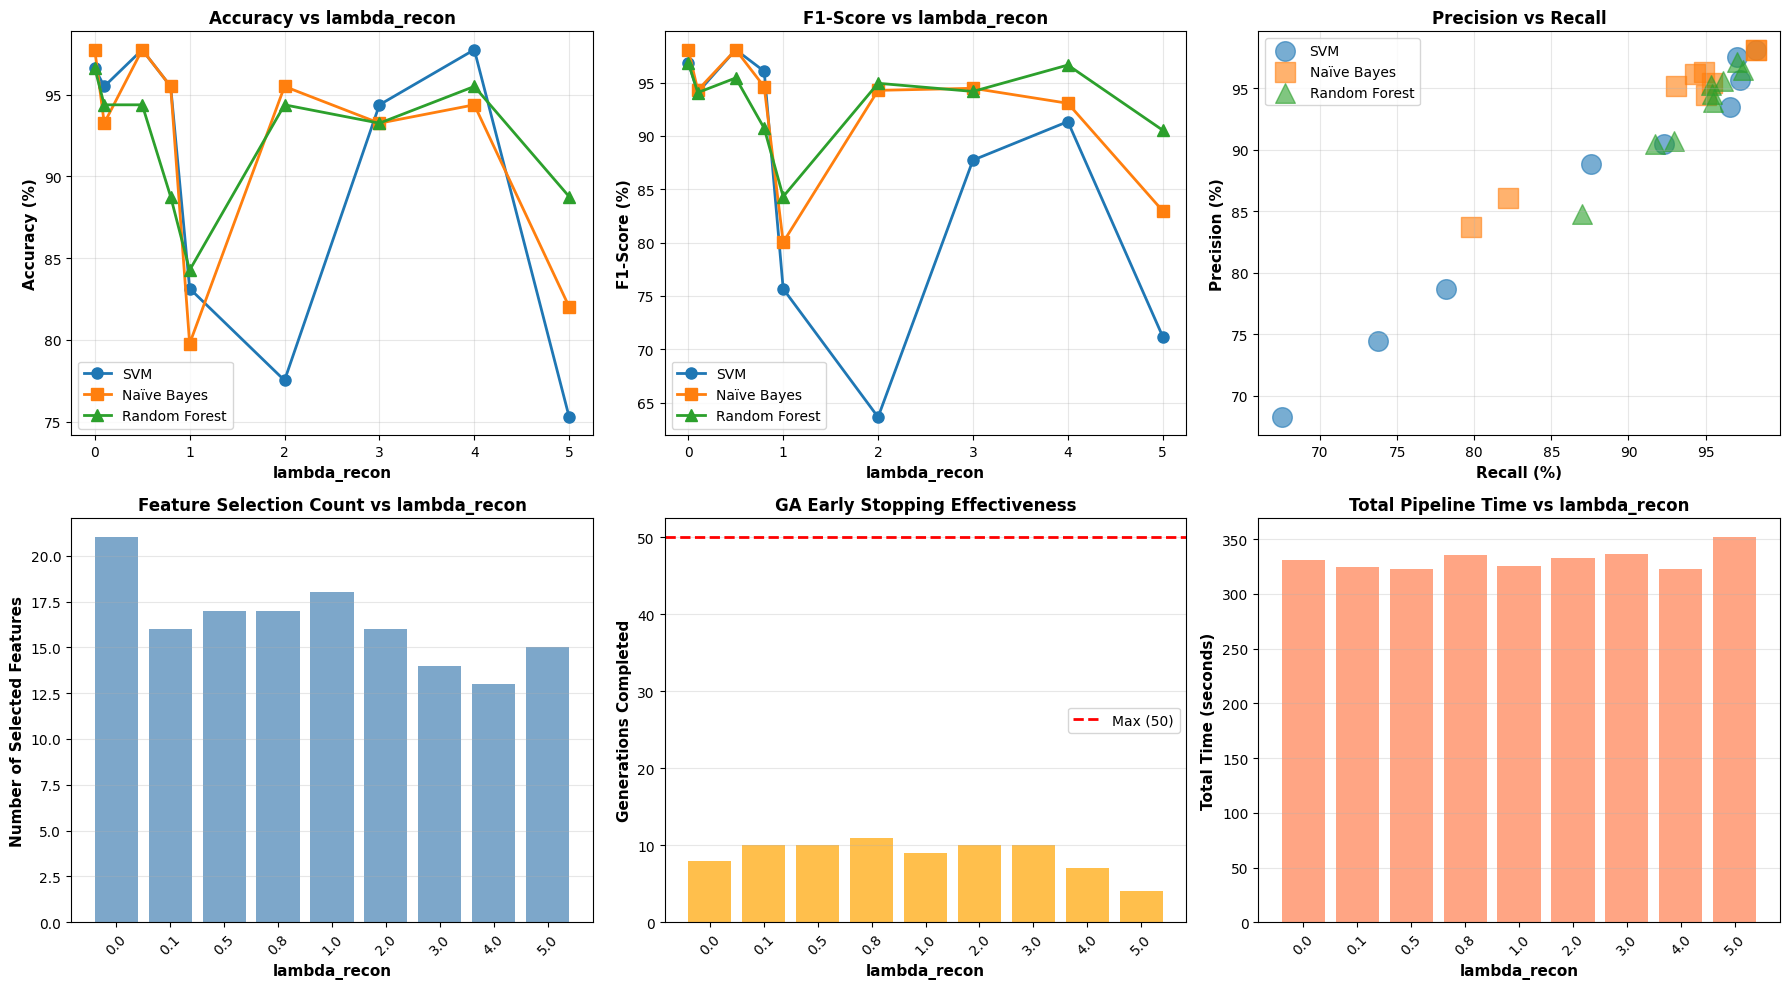


DETAILED COMPARISON TABLE - GA EARLY STOPPING INFO
 lambda_recon  Gens_Completed  Gens_Saved GA_Time(s) Total_Time(s)
          0.0               8          42     318.31        331.26
          0.1              10          40     313.96        324.75
          0.5              10          40     308.71        322.83
          0.8              11          39     325.00        335.60
          1.0               9          41     314.17        325.11
          2.0              10          40     321.42        332.33
          3.0              10          40     325.93        336.25
          4.0               7          43     312.49        323.00
          5.0               4          46     318.59        351.51

EARLY STOPPING STATISTICS
Total generations possible: 450
Total generations actually run: 79
Generations saved by early stopping: 371
Efficiency improvement: 82.4%



In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta


# 1. Data Loading & Preparation

df = pd.read_excel('../minmax.xlsx')
data = df.values
labels = pd.read_csv('../idC_with_header.csv').values.flatten() - 1

X_tensor = torch.tensor(data, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Define the Joint Variational Autoencoder-Classifier Model

class JointVAEClassifier(nn.Module):
    def __init__(self, input_dim, latent_dim=32, num_classes=14):
        super(JointVAEClassifier, self).__init__()
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, input_dim),
            nn.Tanh()  
        )
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        hidden = self.encoder_net(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decoder(z)
        logits = self.classifier(z)
        return reconstruction, logits, mu, logvar


# 3. Loss Functions & Optimizer Setup

reconstruction_loss_fn = nn.MSELoss()
classification_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

def vae_combined_loss(reconstructed, original, logits, labels, mu, logvar, lambda_recon):
    loss_recon = reconstruction_loss_fn(reconstructed, original)
    loss_kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss_class = classification_loss_fn(logits, labels)
    return lambda_recon * (loss_recon + loss_kl) + (1 - lambda_recon) * loss_class

input_dim = data.shape[1]
num_classes = 14
latent_dim = 32
num_epochs = 50

# --- Genetic Algorithm Implementation ---

from deap import base, creator, tools, algorithms
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import random
import warnings
warnings.filterwarnings("ignore")

y_train_np = y_train.numpy()
y_test_np = y_test.numpy()

# GA parameters
LATENT_FEATURES = latent_dim
N_GENERATIONS = 50
POPULATION_SIZE = 50  # Reduced from 100 for faster convergence
P_CROSSOVER = 0.7
P_MUTATION = 0.2
TOURNAMENT_SIZE = 3

# ============================================================================
# EARLY STOPPING PARAMETERS FOR GA
# ============================================================================
GA_PATIENCE = 10              # Stop if no improvement for 10 generations
GA_MAX_TIME = 300             # Max 5 minutes per lambda (in seconds)
GA_MIN_IMPROVEMENT = 0.001    # Only count improvements > 0.1%
# ============================================================================

lambda_values = [0, 0.1, 0.5, 0.8, 1.0, 2.0, 3.0, 4.0, 5.0]

results = {
    'lambda_recon': [],
    'VAE_Training_Time': [],
    'GA_Time': [],
    'GA_Generations_Ran': [],  # NEW: Track how many gens actually ran
    'SVM_Training_Time': [],
    'SVM_Accuracy': [],
    'SVM_Precision': [],
    'SVM_Recall': [],
    'SVM_F1': [],
    'NBC_Training_Time': [],
    'NBC_Accuracy': [],
    'NBC_Precision': [],
    'NBC_Recall': [],
    'NBC_F1': [],
    'RF_Training_Time': [],
    'RF_Accuracy': [],
    'RF_Precision': [],
    'RF_Recall': [],
    'RF_F1': [],
    'Num_Selected_Features': [],
    'Total_Time': []
}

print("="*80)
print("TESTING LAMBDA_RECON VALUES FROM 0 TO 5.0 (WITH EARLY STOPPING GA)")
print("="*80)
print(f"\nGA Early Stopping Settings:")
print(f"  - Patience: {GA_PATIENCE} generations")
print(f"  - Max Time: {GA_MAX_TIME} seconds (~{GA_MAX_TIME/60:.1f} minutes)")
print(f"  - Min Improvement Threshold: {GA_MIN_IMPROVEMENT}")
print(f"  - Population Size: {POPULATION_SIZE}")
print()

for lambda_recon in lambda_values:
    print(f"\n{'='*80}")
    print(f"Testing lambda_recon = {lambda_recon}")
    print(f"{'='*80}")
    
    lambda_start_time = time.time()
    
    # 4. Joint Training
    
    print("=== Joint Training Stage ===")
    vae_start_time = time.time()
    
    model = JointVAEClassifier(input_dim, latent_dim, num_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels_batch in train_loader:
            optimizer.zero_grad()
            reconstruction, logits, mu, logvar = model(inputs)
            loss = vae_combined_loss(reconstruction, inputs, logits, labels_batch, mu, logvar, lambda_recon)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")
    
    vae_training_time = time.time() - vae_start_time
    print(f"VAE Training completed in {timedelta(seconds=int(vae_training_time))}")
    
    # 5. Extract Latent Features
    
    model.eval()
    with torch.no_grad():
        train_encoded = model.encoder_net(X_train)
        train_latent = model.fc_mu(train_encoded).numpy()
        
        test_encoded = model.encoder_net(X_test)
        test_latent = model.fc_mu(test_encoded).numpy()
    
    print("\nRunning Genetic Algorithm for feature selection (with early stopping)...")
    ga_start_time = time.time()
    
    # Clean up DEAP creators
    try:
        del creator.FitnessMax
        del creator.Individual
    except:
        pass
    
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=LATENT_FEATURES)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    
    def evaluate_individual_with_latent(individual):
        selected_indices = [i for i, val in enumerate(individual) if val == 1]
        
        if len(selected_indices) < 2:
            return 0.0,
        
        modified_latent = train_latent[:, selected_indices]
        
        classifier = RandomForestClassifier(random_state=42)
        scores = cross_val_score(classifier, modified_latent, y_train_np, cv=5)
        accuracy = scores.mean()

        return accuracy,
    
    toolbox.register("evaluate", evaluate_individual_with_latent)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)
    
    def run_ga():
        """
        Run GA with early stopping criteria:
        - Stop if no improvement for GA_PATIENCE generations
        - Stop if total time exceeds GA_MAX_TIME seconds
        - Only count improvements > GA_MIN_IMPROVEMENT
        """
        population = toolbox.population(n=POPULATION_SIZE)
        stats = tools.Statistics(lambda ind: ind.fitness.values)
        stats.register("avg", np.mean)
        stats.register("std", np.std)
        stats.register("min", np.min)
        stats.register("max", np.max)
        
        hof = tools.HallOfFame(1)
        
        # Early stopping variables
        best_fitness = -float('inf')
        patience_counter = 0
        ga_elapsed_time = 0
        generations_completed = 0
        
        for gen in range(N_GENERATIONS):
            # Check time elapsed
            if ga_elapsed_time > GA_MAX_TIME:
                print(f"\n  ⏱️  GA Timeout: Exceeded {GA_MAX_TIME}s limit at generation {gen}")
                break
            
            # Run one generation
            population, logbook = algorithms.eaSimple(
                population, 
                toolbox, 
                cxpb=P_CROSSOVER, 
                mutpb=P_MUTATION, 
                ngen=1,  # Run only 1 generation per iteration
                stats=stats, 
                halloffame=hof, 
                verbose=False
            )
            
            generations_completed = gen + 1
            current_best = hof[0].fitness.values[0]
            
            # Check convergence (improvement threshold)
            improvement = current_best - best_fitness
            
            if improvement > GA_MIN_IMPROVEMENT:
                # Significant improvement found
                best_fitness = current_best
                patience_counter = 0
            else:
                # No significant improvement
                patience_counter += 1
            
            # Check if patience exceeded
            if patience_counter >= GA_PATIENCE:
                print(f"\n  ✓ GA Converged: No improvement for {GA_PATIENCE} generations at generation {gen+1}")
                break
            
            # Update elapsed time
            ga_elapsed_time = time.time() - ga_start_time
            
            # Print progress every 10 generations
            if (gen + 1) % 10 == 0:
                print(f"  Gen {gen+1}/{N_GENERATIONS} | Best: {current_best:.4f} | Patience: {patience_counter}/{GA_PATIENCE}")
        
        print(f"  Final: Ran {generations_completed}/{N_GENERATIONS} generations in {timedelta(seconds=int(ga_elapsed_time))}")
        
        return population, logbook, hof, generations_completed
    
    population, logbook, hof, gens_completed = run_ga()
    
    ga_time = time.time() - ga_start_time
    
    best_individual = hof[0]
    selected_latent_features = [i for i, val in enumerate(best_individual) if val == 1]
    num_selected = len(selected_latent_features)
    
    print(f"\nGA Result: {num_selected} features selected out of {LATENT_FEATURES}")
    print(f"Best GA fitness: {best_individual.fitness.values[0]:.4f}")
    
    # 6. Testing the GA selected features on the models
    print("\nTesting GA Selected Features with different classifiers:")
    modified_latent_train = train_latent[:, selected_latent_features]
    modified_latent_test = test_latent[:, selected_latent_features]
    
    # SVM Classifier
    svm_start_time = time.time()
    svm_model = SVC(random_state=42)
    svm_model.fit(modified_latent_train, y_train_np)
    svm_preds = svm_model.predict(modified_latent_test)
    svm_training_time = time.time() - svm_start_time
    
    svm_acc = accuracy_score(y_test_np, svm_preds)
    svm_precision = precision_score(y_test_np, svm_preds, average='macro')
    svm_recall = recall_score(y_test_np, svm_preds, average='macro')
    svm_f1 = f1_score(y_test_np, svm_preds, average='macro')
    
    print(f"  SVM - Acc: {svm_acc*100:.2f}%, Prec: {svm_precision*100:.2f}%, Rec: {svm_recall*100:.2f}%, F1: {svm_f1*100:.2f}%")
    
    # Naïve Bayes Classifier
    nbc_start_time = time.time()
    nbc_model = GaussianNB()
    nbc_model.fit(modified_latent_train, y_train_np)
    nbc_preds = nbc_model.predict(modified_latent_test)
    nbc_training_time = time.time() - nbc_start_time
    
    nbc_acc = accuracy_score(y_test_np, nbc_preds)
    nbc_precision = precision_score(y_test_np, nbc_preds, average='macro')
    nbc_recall = recall_score(y_test_np, nbc_preds, average='macro')
    nbc_f1 = f1_score(y_test_np, nbc_preds, average='macro')
    
    print(f"  NBC - Acc: {nbc_acc*100:.2f}%, Prec: {nbc_precision*100:.2f}%, Rec: {nbc_recall*100:.2f}%, F1: {nbc_f1*100:.2f}%")
    
    # Random Forest Classifier
    rf_start_time = time.time()
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(modified_latent_train, y_train_np)
    rf_preds = rf_model.predict(modified_latent_test)
    rf_training_time = time.time() - rf_start_time
    
    rf_acc = accuracy_score(y_test_np, rf_preds)
    rf_precision = precision_score(y_test_np, rf_preds, average='macro')
    rf_recall = recall_score(y_test_np, rf_preds, average='macro')
    rf_f1 = f1_score(y_test_np, rf_preds, average='macro')
    
    print(f"  RF  - Acc: {rf_acc*100:.2f}%, Prec: {rf_precision*100:.2f}%, Rec: {rf_recall*100:.2f}%, F1: {rf_f1*100:.2f}%")
    
    total_lambda_time = time.time() - lambda_start_time
    print(f"\nTotal time for lambda_recon={lambda_recon}: {timedelta(seconds=int(total_lambda_time))}")
    
    # Store results
    results['lambda_recon'].append(lambda_recon)
    results['VAE_Training_Time'].append(vae_training_time)
    results['GA_Time'].append(ga_time)
    results['GA_Generations_Ran'].append(gens_completed)  # NEW
    results['SVM_Training_Time'].append(svm_training_time)
    results['SVM_Accuracy'].append(svm_acc)
    results['SVM_Precision'].append(svm_precision)
    results['SVM_Recall'].append(svm_recall)
    results['SVM_F1'].append(svm_f1)
    results['NBC_Training_Time'].append(nbc_training_time)
    results['NBC_Accuracy'].append(nbc_acc)
    results['NBC_Precision'].append(nbc_precision)
    results['NBC_Recall'].append(nbc_recall)
    results['NBC_F1'].append(nbc_f1)
    results['RF_Training_Time'].append(rf_training_time)
    results['RF_Accuracy'].append(rf_acc)
    results['RF_Precision'].append(rf_precision)
    results['RF_Recall'].append(rf_recall)
    results['RF_F1'].append(rf_f1)
    results['Num_Selected_Features'].append(num_selected)
    results['Total_Time'].append(total_lambda_time)

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETED")
print(f"{'='*80}\n")

results_df = pd.DataFrame(results)
print("Summary of Results:")
print(results_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Accuracy Comparison
axes[0, 0].plot(results['lambda_recon'], np.array(results['SVM_Accuracy']) * 100, 'o-', label='SVM', linewidth=2, markersize=8)
axes[0, 0].plot(results['lambda_recon'], np.array(results['NBC_Accuracy']) * 100, 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[0, 0].plot(results['lambda_recon'], np.array(results['RF_Accuracy']) * 100, '^-', label='Random Forest', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Accuracy vs lambda_recon', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: F1-Score Comparison
axes[0, 1].plot(results['lambda_recon'], np.array(results['SVM_F1']) * 100, 'o-', label='SVM', linewidth=2, markersize=8)
axes[0, 1].plot(results['lambda_recon'], np.array(results['NBC_F1']) * 100, 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[0, 1].plot(results['lambda_recon'], np.array(results['RF_F1']) * 100, '^-', label='Random Forest', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('F1-Score (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('F1-Score vs lambda_recon', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision vs Recall
axes[0, 2].scatter(np.array(results['SVM_Recall']) * 100, np.array(results['SVM_Precision']) * 100, 
                   s=200, alpha=0.6, label='SVM', marker='o')
axes[0, 2].scatter(np.array(results['NBC_Recall']) * 100, np.array(results['NBC_Precision']) * 100, 
                   s=200, alpha=0.6, label='Naïve Bayes', marker='s')
axes[0, 2].scatter(np.array(results['RF_Recall']) * 100, np.array(results['RF_Precision']) * 100, 
                   s=200, alpha=0.6, label='Random Forest', marker='^')
axes[0, 2].set_xlabel('Recall (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Precision vs Recall', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Number of Selected Features
axes[1, 0].bar(range(len(results['lambda_recon'])), results['Num_Selected_Features'], color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Number of Selected Features', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Feature Selection Count vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(len(results['lambda_recon'])))
axes[1, 0].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: GA Generations Completed (NEW - Shows early stopping effectiveness)
axes[1, 1].bar(range(len(results['lambda_recon'])), results['GA_Generations_Ran'], color='orange', alpha=0.7)
axes[1, 1].axhline(y=N_GENERATIONS, color='red', linestyle='--', linewidth=2, label=f'Max ({N_GENERATIONS})')
axes[1, 1].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Generations Completed', fontsize=11, fontweight='bold')
axes[1, 1].set_title('GA Early Stopping Effectiveness', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(len(results['lambda_recon'])))
axes[1, 1].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Plot 6: Total Pipeline Time per Lambda
axes[1, 2].bar(range(len(results['lambda_recon'])), results['Total_Time'], color='coral', alpha=0.7)
axes[1, 2].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('Total Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Total Pipeline Time vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(range(len(results['lambda_recon'])))
axes[1, 2].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("DETAILED COMPARISON TABLE - GA EARLY STOPPING INFO")
print("="*120)

ga_info_table = pd.DataFrame({
    'lambda_recon': results['lambda_recon'],
    'Gens_Completed': results['GA_Generations_Ran'],
    'Gens_Saved': [N_GENERATIONS - x for x in results['GA_Generations_Ran']],
    'GA_Time(s)': [f"{x:.2f}" for x in results['GA_Time']],
    'Total_Time(s)': [f"{x:.2f}" for x in results['Total_Time']],
})

print(ga_info_table.to_string(index=False))

print("\n" + "="*120)
print("EARLY STOPPING STATISTICS")
print("="*120)

total_gens_possible = N_GENERATIONS * len(lambda_values)
total_gens_ran = sum(results['GA_Generations_Ran'])
gens_saved = total_gens_possible - total_gens_ran
percent_saved = (gens_saved / total_gens_possible) * 100

print(f"Total generations possible: {total_gens_possible}")
print(f"Total generations actually run: {total_gens_ran}")
print(f"Generations saved by early stopping: {gens_saved}")
print(f"Efficiency improvement: {percent_saved:.1f}%")

print("\n" + "="*120)

**Disgarding time constraint**

TESTING LAMBDA_RECON VALUES FROM 0 TO 5.0 (WITH EARLY STOPPING GA)

GA Early Stopping Settings:
  - Patience: 10 generations
  - Min Improvement Threshold: 0.001
  - Population Size: 50


Testing lambda_recon = 0
=== Joint Training Stage ===
  Epoch [10/50], Loss: 1.0555
  Epoch [20/50], Loss: 0.8192
  Epoch [30/50], Loss: 0.7156
  Epoch [40/50], Loss: 0.7700
  Epoch [50/50], Loss: 0.8494
VAE Training completed in 0:00:12

Running Genetic Algorithm for feature selection (with early stopping)...
  Gen 10/50 | Best: 1.0000 | Patience: 9/10

  ✓ GA Converged: No improvement for 10 generations at generation 11
  Final: Ran 11/50 generations

GA Result: 10 features selected out of 32
Best GA fitness: 1.0000

Testing GA Selected Features with different classifiers:
  SVM - Acc: 97.75%, Prec: 98.08%, Rec: 99.15%, F1: 98.45%
  NBC - Acc: 97.75%, Prec: 98.08%, Rec: 99.15%, F1: 98.45%
  RF  - Acc: 94.38%, Prec: 93.59%, Rec: 97.01%, F1: 94.68%

Total time for lambda_recon=0: 0:05:57

Testing lamb

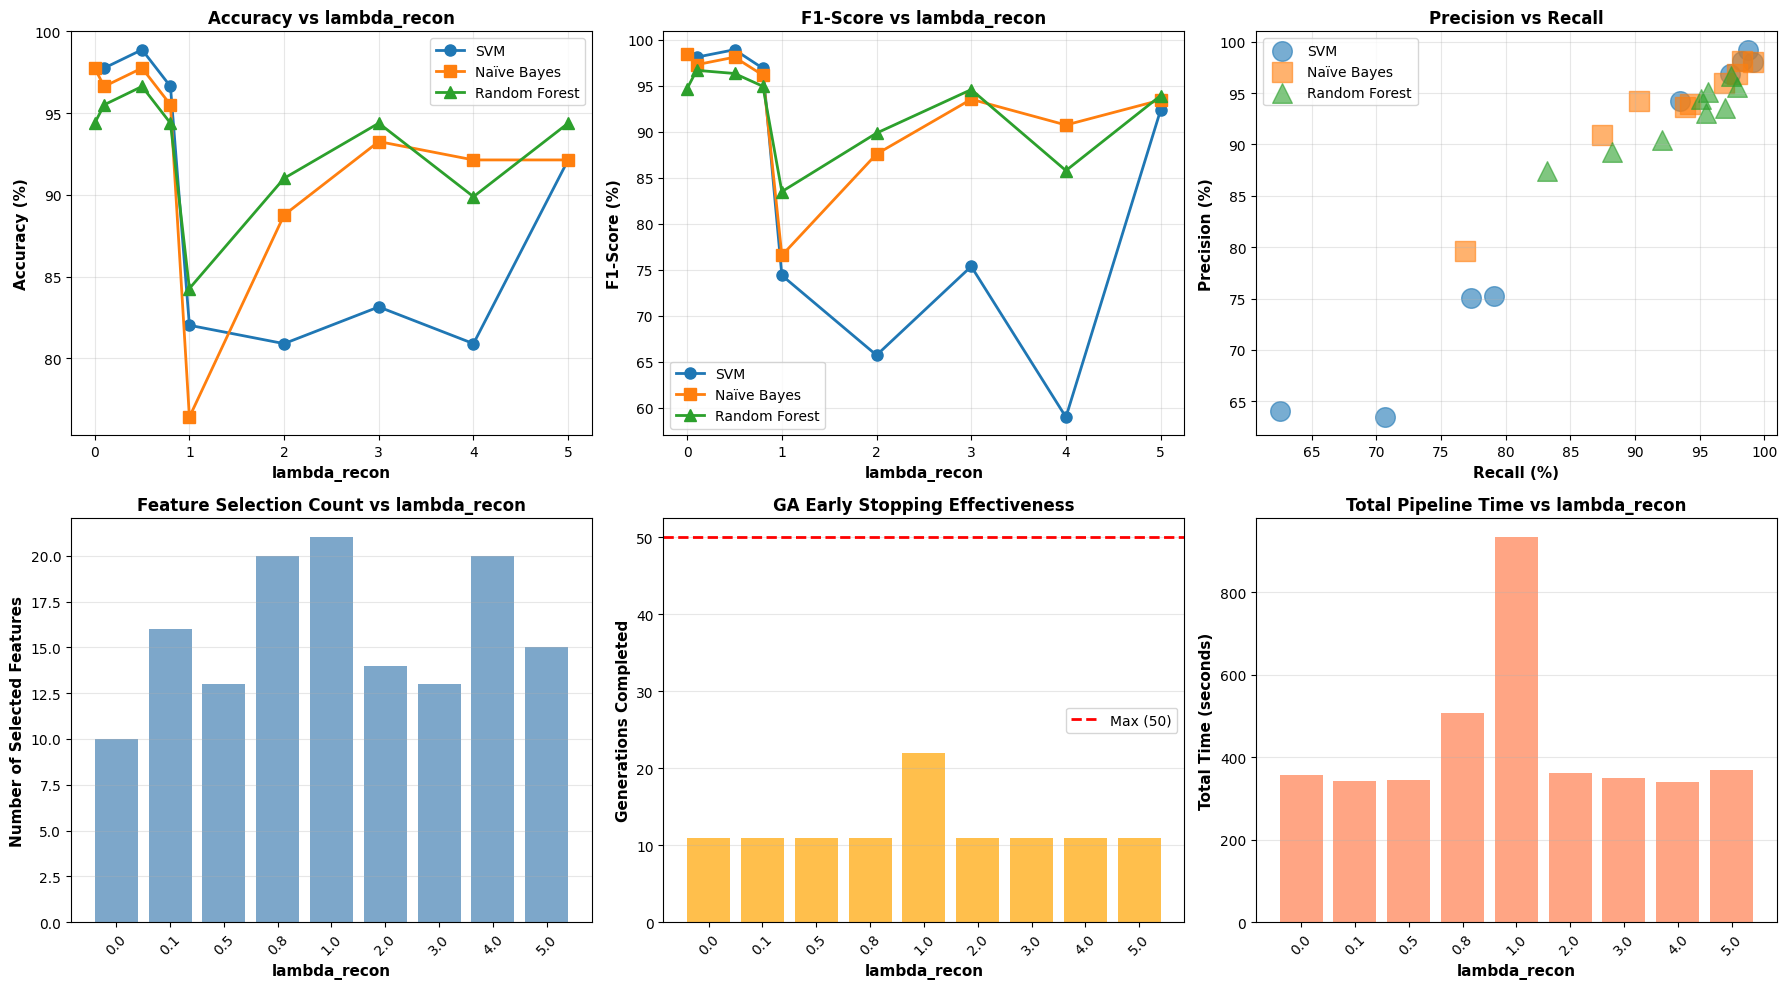


DETAILED COMPARISON TABLE - GA EARLY STOPPING INFO
 lambda_recon  Gens_Completed  Gens_Saved GA_Time(s) Total_Time(s)
          0.0              11          39     344.55        357.46
          0.1              11          39     330.58        342.31
          0.5              11          39     331.23        345.26
          0.8              11          39     489.49        507.57
          1.0              22          28     922.52        933.76
          2.0              11          39     351.55        361.63
          3.0              11          39     338.70        350.17
          4.0              11          39     328.04        340.11
          5.0              11          39     355.15        370.17

EARLY STOPPING STATISTICS
Total generations possible: 450
Total generations actually run: 110
Generations saved by early stopping: 340
Efficiency improvement: 75.6%



In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta


# 1. Data Loading & Preparation

df = pd.read_excel('../minmax.xlsx')
data = df.values
labels = pd.read_csv('../idC_with_header.csv').values.flatten() - 1

X_tensor = torch.tensor(data, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Define the Joint Variational Autoencoder-Classifier Model

class JointVAEClassifier(nn.Module):
    def __init__(self, input_dim, latent_dim=32, num_classes=14):
        super(JointVAEClassifier, self).__init__()
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, input_dim),
            nn.Tanh()  
        )
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        hidden = self.encoder_net(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decoder(z)
        logits = self.classifier(z)
        return reconstruction, logits, mu, logvar


# 3. Loss Functions & Optimizer Setup

reconstruction_loss_fn = nn.MSELoss()
classification_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

def vae_combined_loss(reconstructed, original, logits, labels, mu, logvar, lambda_recon):
    loss_recon = reconstruction_loss_fn(reconstructed, original)
    loss_kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss_class = classification_loss_fn(logits, labels)
    return lambda_recon * (loss_recon + loss_kl) + (1 - lambda_recon) * loss_class

input_dim = data.shape[1]
num_classes = 14
latent_dim = 32
num_epochs = 50

# --- Genetic Algorithm Implementation ---

from deap import base, creator, tools, algorithms
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import random
import warnings
warnings.filterwarnings("ignore")

y_train_np = y_train.numpy()
y_test_np = y_test.numpy()

# GA parameters
LATENT_FEATURES = latent_dim
N_GENERATIONS = 50
POPULATION_SIZE = 50  # Reduced from 100 for faster convergence
P_CROSSOVER = 0.7
P_MUTATION = 0.2
TOURNAMENT_SIZE = 3

# ============================================================================
# EARLY STOPPING PARAMETERS FOR GA
# ============================================================================
GA_PATIENCE = 10              # Stop if no improvement for 10 generations
GA_MIN_IMPROVEMENT = 0.001    # Only count improvements > 0.1%
# ============================================================================

lambda_values = [0, 0.1, 0.5, 0.8, 1.0, 2.0, 3.0, 4.0, 5.0]

results = {
    'lambda_recon': [],
    'VAE_Training_Time': [],
    'GA_Time': [],
    'GA_Generations_Ran': [],  # NEW: Track how many gens actually ran
    'SVM_Training_Time': [],
    'SVM_Accuracy': [],
    'SVM_Precision': [],
    'SVM_Recall': [],
    'SVM_F1': [],
    'NBC_Training_Time': [],
    'NBC_Accuracy': [],
    'NBC_Precision': [],
    'NBC_Recall': [],
    'NBC_F1': [],
    'RF_Training_Time': [],
    'RF_Accuracy': [],
    'RF_Precision': [],
    'RF_Recall': [],
    'RF_F1': [],
    'Num_Selected_Features': [],
    'Total_Time': []
}

print("="*80)
print("TESTING LAMBDA_RECON VALUES FROM 0 TO 5.0 (WITH EARLY STOPPING GA)")
print("="*80)
print(f"\nGA Early Stopping Settings:")
print(f"  - Patience: {GA_PATIENCE} generations")
print(f"  - Min Improvement Threshold: {GA_MIN_IMPROVEMENT}")
print(f"  - Population Size: {POPULATION_SIZE}")
print()

for lambda_recon in lambda_values:
    print(f"\n{'='*80}")
    print(f"Testing lambda_recon = {lambda_recon}")
    print(f"{'='*80}")
    
    lambda_start_time = time.time()
    
    # 4. Joint Training
    
    print("=== Joint Training Stage ===")
    vae_start_time = time.time()
    
    model = JointVAEClassifier(input_dim, latent_dim, num_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels_batch in train_loader:
            optimizer.zero_grad()
            reconstruction, logits, mu, logvar = model(inputs)
            loss = vae_combined_loss(reconstruction, inputs, logits, labels_batch, mu, logvar, lambda_recon)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")
    
    vae_training_time = time.time() - vae_start_time
    print(f"VAE Training completed in {timedelta(seconds=int(vae_training_time))}")
    
    # 5. Extract Latent Features
    
    model.eval()
    with torch.no_grad():
        train_encoded = model.encoder_net(X_train)
        train_latent = model.fc_mu(train_encoded).numpy()
        
        test_encoded = model.encoder_net(X_test)
        test_latent = model.fc_mu(test_encoded).numpy()
    
    print("\nRunning Genetic Algorithm for feature selection (with early stopping)...")
    ga_start_time = time.time()
    
    # Clean up DEAP creators
    try:
        del creator.FitnessMax
        del creator.Individual
    except:
        pass
    
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=LATENT_FEATURES)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    
    def evaluate_individual_with_latent(individual):
        selected_indices = [i for i, val in enumerate(individual) if val == 1]
        
        if len(selected_indices) < 2:
            return 0.0,
        
        modified_latent = train_latent[:, selected_indices]
        
        classifier = RandomForestClassifier(random_state=42)
        scores = cross_val_score(classifier, modified_latent, y_train_np, cv=5)
        accuracy = scores.mean()

        return accuracy,
    
    toolbox.register("evaluate", evaluate_individual_with_latent)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)
    
    def run_ga():
        """
        Run GA with early stopping criteria:
        - Stop if no improvement for GA_PATIENCE generations
        - Only count improvements > GA_MIN_IMPROVEMENT
        """
        population = toolbox.population(n=POPULATION_SIZE)
        stats = tools.Statistics(lambda ind: ind.fitness.values)
        stats.register("avg", np.mean)
        stats.register("std", np.std)
        stats.register("min", np.min)
        stats.register("max", np.max)
        
        hof = tools.HallOfFame(1)
        
        # Early stopping variables
        best_fitness = -float('inf')
        patience_counter = 0
        generations_completed = 0
        
        for gen in range(N_GENERATIONS):
            # Run one generation
            population, logbook = algorithms.eaSimple(
                population, 
                toolbox, 
                cxpb=P_CROSSOVER, 
                mutpb=P_MUTATION, 
                ngen=1,  # Run only 1 generation per iteration
                stats=stats, 
                halloffame=hof, 
                verbose=False
            )
            
            generations_completed = gen + 1
            current_best = hof[0].fitness.values[0]
            
            # Check convergence (improvement threshold)
            improvement = current_best - best_fitness
            
            if improvement > GA_MIN_IMPROVEMENT:
                # Significant improvement found
                best_fitness = current_best
                patience_counter = 0
            else:
                # No significant improvement
                patience_counter += 1
            
            # Check if patience exceeded
            if patience_counter >= GA_PATIENCE:
                print(f"\n  ✓ GA Converged: No improvement for {GA_PATIENCE} generations at generation {gen+1}")
                break
            
            # Print progress every 10 generations
            if (gen + 1) % 10 == 0:
                print(f"  Gen {gen+1}/{N_GENERATIONS} | Best: {current_best:.4f} | Patience: {patience_counter}/{GA_PATIENCE}")
        
        print(f"  Final: Ran {generations_completed}/{N_GENERATIONS} generations")
        
        return population, logbook, hof, generations_completed
    
    population, logbook, hof, gens_completed = run_ga()
    
    ga_time = time.time() - ga_start_time
    
    best_individual = hof[0]
    selected_latent_features = [i for i, val in enumerate(best_individual) if val == 1]
    num_selected = len(selected_latent_features)
    
    print(f"\nGA Result: {num_selected} features selected out of {LATENT_FEATURES}")
    print(f"Best GA fitness: {best_individual.fitness.values[0]:.4f}")
    
    # 6. Testing the GA selected features on the models
    print("\nTesting GA Selected Features with different classifiers:")
    modified_latent_train = train_latent[:, selected_latent_features]
    modified_latent_test = test_latent[:, selected_latent_features]
    
    # SVM Classifier
    svm_start_time = time.time()
    svm_model = SVC(random_state=42)
    svm_model.fit(modified_latent_train, y_train_np)
    svm_preds = svm_model.predict(modified_latent_test)
    svm_training_time = time.time() - svm_start_time
    
    svm_acc = accuracy_score(y_test_np, svm_preds)
    svm_precision = precision_score(y_test_np, svm_preds, average='macro')
    svm_recall = recall_score(y_test_np, svm_preds, average='macro')
    svm_f1 = f1_score(y_test_np, svm_preds, average='macro')
    
    print(f"  SVM - Acc: {svm_acc*100:.2f}%, Prec: {svm_precision*100:.2f}%, Rec: {svm_recall*100:.2f}%, F1: {svm_f1*100:.2f}%")
    
    # Naïve Bayes Classifier
    nbc_start_time = time.time()
    nbc_model = GaussianNB()
    nbc_model.fit(modified_latent_train, y_train_np)
    nbc_preds = nbc_model.predict(modified_latent_test)
    nbc_training_time = time.time() - nbc_start_time
    
    nbc_acc = accuracy_score(y_test_np, nbc_preds)
    nbc_precision = precision_score(y_test_np, nbc_preds, average='macro')
    nbc_recall = recall_score(y_test_np, nbc_preds, average='macro')
    nbc_f1 = f1_score(y_test_np, nbc_preds, average='macro')
    
    print(f"  NBC - Acc: {nbc_acc*100:.2f}%, Prec: {nbc_precision*100:.2f}%, Rec: {nbc_recall*100:.2f}%, F1: {nbc_f1*100:.2f}%")
    
    # Random Forest Classifier
    rf_start_time = time.time()
    rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_model.fit(modified_latent_train, y_train_np)
    rf_preds = rf_model.predict(modified_latent_test)
    rf_training_time = time.time() - rf_start_time
    
    rf_acc = accuracy_score(y_test_np, rf_preds)
    rf_precision = precision_score(y_test_np, rf_preds, average='macro')
    rf_recall = recall_score(y_test_np, rf_preds, average='macro')
    rf_f1 = f1_score(y_test_np, rf_preds, average='macro')
    
    print(f"  RF  - Acc: {rf_acc*100:.2f}%, Prec: {rf_precision*100:.2f}%, Rec: {rf_recall*100:.2f}%, F1: {rf_f1*100:.2f}%")
    
    total_lambda_time = time.time() - lambda_start_time
    print(f"\nTotal time for lambda_recon={lambda_recon}: {timedelta(seconds=int(total_lambda_time))}")
    
    # Store results
    results['lambda_recon'].append(lambda_recon)
    results['VAE_Training_Time'].append(vae_training_time)
    results['GA_Time'].append(ga_time)
    results['GA_Generations_Ran'].append(gens_completed)  # NEW
    results['SVM_Training_Time'].append(svm_training_time)
    results['SVM_Accuracy'].append(svm_acc)
    results['SVM_Precision'].append(svm_precision)
    results['SVM_Recall'].append(svm_recall)
    results['SVM_F1'].append(svm_f1)
    results['NBC_Training_Time'].append(nbc_training_time)
    results['NBC_Accuracy'].append(nbc_acc)
    results['NBC_Precision'].append(nbc_precision)
    results['NBC_Recall'].append(nbc_recall)
    results['NBC_F1'].append(nbc_f1)
    results['RF_Training_Time'].append(rf_training_time)
    results['RF_Accuracy'].append(rf_acc)
    results['RF_Precision'].append(rf_precision)
    results['RF_Recall'].append(rf_recall)
    results['RF_F1'].append(rf_f1)
    results['Num_Selected_Features'].append(num_selected)
    results['Total_Time'].append(total_lambda_time)

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETED")
print(f"{'='*80}\n")

results_df = pd.DataFrame(results)
print("Summary of Results:")
print(results_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Accuracy Comparison
axes[0, 0].plot(results['lambda_recon'], np.array(results['SVM_Accuracy']) * 100, 'o-', label='SVM', linewidth=2, markersize=8)
axes[0, 0].plot(results['lambda_recon'], np.array(results['NBC_Accuracy']) * 100, 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[0, 0].plot(results['lambda_recon'], np.array(results['RF_Accuracy']) * 100, '^-', label='Random Forest', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Accuracy vs lambda_recon', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: F1-Score Comparison
axes[0, 1].plot(results['lambda_recon'], np.array(results['SVM_F1']) * 100, 'o-', label='SVM', linewidth=2, markersize=8)
axes[0, 1].plot(results['lambda_recon'], np.array(results['NBC_F1']) * 100, 's-', label='Naïve Bayes', linewidth=2, markersize=8)
axes[0, 1].plot(results['lambda_recon'], np.array(results['RF_F1']) * 100, '^-', label='Random Forest', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('F1-Score (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('F1-Score vs lambda_recon', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision vs Recall
axes[0, 2].scatter(np.array(results['SVM_Recall']) * 100, np.array(results['SVM_Precision']) * 100, 
                   s=200, alpha=0.6, label='SVM', marker='o')
axes[0, 2].scatter(np.array(results['NBC_Recall']) * 100, np.array(results['NBC_Precision']) * 100, 
                   s=200, alpha=0.6, label='Naïve Bayes', marker='s')
axes[0, 2].scatter(np.array(results['RF_Recall']) * 100, np.array(results['RF_Precision']) * 100, 
                   s=200, alpha=0.6, label='Random Forest', marker='^')
axes[0, 2].set_xlabel('Recall (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Precision vs Recall', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Number of Selected Features
axes[1, 0].bar(range(len(results['lambda_recon'])), results['Num_Selected_Features'], color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Number of Selected Features', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Feature Selection Count vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(len(results['lambda_recon'])))
axes[1, 0].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: GA Generations Completed (NEW - Shows early stopping effectiveness)
axes[1, 1].bar(range(len(results['lambda_recon'])), results['GA_Generations_Ran'], color='orange', alpha=0.7)
axes[1, 1].axhline(y=N_GENERATIONS, color='red', linestyle='--', linewidth=2, label=f'Max ({N_GENERATIONS})')
axes[1, 1].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Generations Completed', fontsize=11, fontweight='bold')
axes[1, 1].set_title('GA Early Stopping Effectiveness', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(len(results['lambda_recon'])))
axes[1, 1].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Plot 6: Total Pipeline Time per Lambda
axes[1, 2].bar(range(len(results['lambda_recon'])), results['Total_Time'], color='coral', alpha=0.7)
axes[1, 2].set_xlabel('lambda_recon', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('Total Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Total Pipeline Time vs lambda_recon', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(range(len(results['lambda_recon'])))
axes[1, 2].set_xticklabels([f"{x:.1f}" for x in results['lambda_recon']], rotation=45)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("DETAILED COMPARISON TABLE - GA EARLY STOPPING INFO")
print("="*120)

ga_info_table = pd.DataFrame({
    'lambda_recon': results['lambda_recon'],
    'Gens_Completed': results['GA_Generations_Ran'],
    'Gens_Saved': [N_GENERATIONS - x for x in results['GA_Generations_Ran']],
    'GA_Time(s)': [f"{x:.2f}" for x in results['GA_Time']],
    'Total_Time(s)': [f"{x:.2f}" for x in results['Total_Time']],
})

print(ga_info_table.to_string(index=False))

print("\n" + "="*120)
print("EARLY STOPPING STATISTICS")
print("="*120)

total_gens_possible = N_GENERATIONS * len(lambda_values)
total_gens_ran = sum(results['GA_Generations_Ran'])
gens_saved = total_gens_possible - total_gens_ran
percent_saved = (gens_saved / total_gens_possible) * 100

print(f"Total generations possible: {total_gens_possible}")
print(f"Total generations actually run: {total_gens_ran}")
print(f"Generations saved by early stopping: {gens_saved}")
print(f"Efficiency improvement: {percent_saved:.1f}%")

print("\n" + "="*120)